In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import zipfile
import io

#CARGA DATOS ARTICULOS

In [ ]:
# Cargar los datos de los archivos de ventas
articu = pd.read_csv("Articu.csv", encoding='latin1', delimiter=';')
articu

,Descripcion,IdArticu,StockActual,FechaUltimaEntrada,FechaCaducidad,Puc,Pmc,Pvp,ProveedorHabitual,Laboratorio
0,DESCUENTO PROMOCION,0,0,NaN,NaN,0.00000,0.00,2.00,,
1,PAGO A CUENTA,1,0,NaN,NaN,14.90000,0.00,50.00,,
2,ARTICULOS VARIOS,2,1,NaN,NaN,1.00680,4.05,0.00,,
3,ALCOHOL BORICADO A SATURACION (5%) 100 ML SOLUCI,3,0,NaN,NaN,0.00000,0.00,15.27,NaN,
4,DROSERA HOMACCORD 30 ML GOTAS,4,0,2016-12-01 00:00:00.000,NaN,11.66220,11.66,16.10,0032,E5154
...,...,...,...,...,...,...,...,...,...,...
27536,ORGAMETRIL 5 MG 30 COMPRIMIDOS,999926,0,NaN,NaN,2.12000,2.12,3.03,,E0849
27537,CEPRANDAL 20 MG 28 CAPSULAS GASTRORRESISTENTES,999932,0,2015-02-13 00:00:00.000,NaN,1.63270,1.63,2.42,,E0494
27538,DOXORUBICINA TEDEC 50 MG 1 VIAL SOLUCION 25 ML,999958,0,2022-07-12 00:00:00.000,NaN,14.41055,14.41,21.31,,E0624
27539,"COFARES CLAVE ""CEROS""/ENCARGO VALENCIA 450 U.",999995,0,2017-02-13 00:00:00.000,NaN,0.00000,0.00,0.00,,


In [ ]:
familias = pd.read_csv("FamArticu.csv", encoding='latin1', delimiter=';')
familias

,IdArticu,IdFamilia,Familia
0,12,4,DIETETICA
1,22,4,DIETETICA
2,33,13,ORTOPEDIA / BOTIQUIN
3,36,4,DIETETICA
4,37,4,DIETETICA
...,...,...,...
15508,999907,2,ESPECIALIDADES
15509,999921,23,ESP.ÊÊÊE.F.G
15510,999923,2,ESPECIALIDADES
15511,999958,23,ESP.ÊÊÊE.F.G


In [ ]:
# Combinar los datos para añadir el grupo de familia de los articulos
articulos = pd.merge(articu, familias, on="IdArticu", how="left")
articulos

,Descripcion,IdArticu,StockActual,FechaUltimaEntrada,FechaCaducidad,Puc,Pmc,Pvp,ProveedorHabitual,Laboratorio,IdFamilia,Familia
0,DESCUENTO PROMOCION,0,0,NaN,NaN,0.00000,0.00,2.00,,,NaN,NaN
1,PAGO A CUENTA,1,0,NaN,NaN,14.90000,0.00,50.00,,,NaN,NaN
2,ARTICULOS VARIOS,2,1,NaN,NaN,1.00680,4.05,0.00,,,NaN,NaN
3,ALCOHOL BORICADO A SATURACION (5%) 100 ML SOLUCI,3,0,NaN,NaN,0.00000,0.00,15.27,NaN,,NaN,NaN
4,DROSERA HOMACCORD 30 ML GOTAS,4,0,2016-12-01 00:00:00.000,NaN,11.66220,11.66,16.10,0032,E5154,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
27536,ORGAMETRIL 5 MG 30 COMPRIMIDOS,999926,0,NaN,NaN,2.12000,2.12,3.03,,E0849,NaN,NaN
27537,CEPRANDAL 20 MG 28 CAPSULAS GASTRORRESISTENTES,999932,0,2015-02-13 00:00:00.000,NaN,1.63270,1.63,2.42,,E0494,NaN,NaN
27538,DOXORUBICINA TEDEC 50 MG 1 VIAL SOLUCION 25 ML,999958,0,2022-07-12 00:00:00.000,NaN,14.41055,14.41,21.31,,E0624,23.0,ESP.ÊÊÊE.F.G
27539,"COFARES CLAVE ""CEROS""/ENCARGO VALENCIA 450 U.",999995,0,2017-02-13 00:00:00.000,NaN,0.00000,0.00,0.00,,,NaN,NaN


In [ ]:
# Convertir la columna de fecha de venta a tipo datetime si no lo está
articulos['FechaUltimaEntrada'] = pd.to_datetime(articulos['FechaUltimaEntrada'])
articulos['FechaCaducidad'] = pd.to_datetime(articulos['FechaCaducidad'])
# Eliminar las filas con fechas anteriores a 2020 en la columna 'FechaUltimaEntrada'
articulos = articulos[articulos['FechaUltimaEntrada'] >= pd.to_datetime("2020-01-01")]

articulos

,Descripcion,IdArticu,StockActual,FechaUltimaEntrada,FechaCaducidad,Puc,Pmc,Pvp,ProveedorHabitual,Laboratorio,IdFamilia,Familia
11,ALGAS 104 COMP -ANA M» LA JUSTICIA-,12,0,2023-05-08,NaT,8.39960,6.73,11.85,,P1458,4.0,DIETETICA
19,OLEUM DERMA DI POMPEIA REGEN. Y VITAL. 50 ML,22,1,2022-09-06,NaT,31.25970,31.26,37.85,0032,,4.0,DIETETICA
30,MCDAVID PERNERA T-XL,33,1,2022-08-04,NaT,27.79430,27.79,30.95,,,13.0,ORTOPEDIA / BOTIQUIN
33,SYMBIO FLOR 2 50ML ACTIBIOS,36,0,2023-05-15,NaT,14.56000,13.07,17.90,0032,,4.0,DIETETICA
34,SYMBIO FLOR 1 GOTAS 50ML -SYMBIOPHARM-,37,0,2022-08-05,NaT,13.50000,13.50,18.50,0032,,4.0,DIETETICA
...,...,...,...,...,...,...,...,...,...,...,...,...
27533,MINITRAN 15 MG/24 H 30 PARCHES TRANSDERMICOS 54,999907,1,2023-10-09,2024-01-31,15.64365,15.64,23.14,,E1011,2.0,ESPECIALIDADES
27534,ALPRAZOLAM MYLAN EFG 2 MG 30 COMPRIMIDOS,999921,1,2023-10-04,2025-06-30,3.27085,3.27,4.84,,E1011,23.0,ESP.ÊÊÊE.F.G
27535,ALERGOLIBER 10 MG 20 COMPRIMIDOS,999923,2,2023-11-12,2026-02-28,4.71295,4.71,6.98,0001,E0456,2.0,ESPECIALIDADES
27538,DOXORUBICINA TEDEC 50 MG 1 VIAL SOLUCION 25 ML,999958,0,2022-07-12,NaT,14.41055,14.41,21.31,,E0624,23.0,ESP.ÊÊÊE.F.G


In [ ]:
# Comprobamos si el dataset contiene valores nulos
valores_faltantes = articulos.isna().any().any()

if valores_faltantes:
    print("El DataFrame contiene valores nulos (NaN).")
    articulos = articulos.dropna(subset=['FechaUltimaEntrada'])


else:
    print("El DataFrame no contiene valores nulos (NaN).")

articulos

El DataFrame contiene valores nulos (NaN).


,Descripcion,IdArticu,StockActual,FechaUltimaEntrada,FechaCaducidad,Puc,Pmc,Pvp,ProveedorHabitual,Laboratorio,IdFamilia,Familia
11,ALGAS 104 COMP -ANA M» LA JUSTICIA-,12,0,2023-05-08,NaT,8.39960,6.73,11.85,,P1458,4.0,DIETETICA
19,OLEUM DERMA DI POMPEIA REGEN. Y VITAL. 50 ML,22,1,2022-09-06,NaT,31.25970,31.26,37.85,0032,,4.0,DIETETICA
30,MCDAVID PERNERA T-XL,33,1,2022-08-04,NaT,27.79430,27.79,30.95,,,13.0,ORTOPEDIA / BOTIQUIN
33,SYMBIO FLOR 2 50ML ACTIBIOS,36,0,2023-05-15,NaT,14.56000,13.07,17.90,0032,,4.0,DIETETICA
34,SYMBIO FLOR 1 GOTAS 50ML -SYMBIOPHARM-,37,0,2022-08-05,NaT,13.50000,13.50,18.50,0032,,4.0,DIETETICA
...,...,...,...,...,...,...,...,...,...,...,...,...
27533,MINITRAN 15 MG/24 H 30 PARCHES TRANSDERMICOS 54,999907,1,2023-10-09,2024-01-31,15.64365,15.64,23.14,,E1011,2.0,ESPECIALIDADES
27534,ALPRAZOLAM MYLAN EFG 2 MG 30 COMPRIMIDOS,999921,1,2023-10-04,2025-06-30,3.27085,3.27,4.84,,E1011,23.0,ESP.ÊÊÊE.F.G
27535,ALERGOLIBER 10 MG 20 COMPRIMIDOS,999923,2,2023-11-12,2026-02-28,4.71295,4.71,6.98,0001,E0456,2.0,ESPECIALIDADES
27538,DOXORUBICINA TEDEC 50 MG 1 VIAL SOLUCION 25 ML,999958,0,2022-07-12,NaT,14.41055,14.41,21.31,,E0624,23.0,ESP.ÊÊÊE.F.G


# CARGA DATOS VENTAS

In [ ]:
# Listas para almacenar los DataFrames de ventas y líneas de venta
ventas_dfs = []
lineas_dfs = []

# Cargar los datos de ventas y líneas de venta para cada año desde 2017 hasta 2023
for year in range(2020, 2023):
    # Nombre de los archivos CSV para ventas y líneas de venta
    venta_file = f"venta({year}).csv"
    lventa_file = f"lineaventa({year}).csv"

    # Cargar los datos de ventas y líneas de venta
    ventas_df = pd.read_csv(venta_file, delimiter=';')
    lineas_df = pd.read_csv(lventa_file, delimiter=';')

    # Combina los datos de ventas con los datos de líneas de venta utilizando el campo IdVenta
    ventas_lineas_df = pd.merge(ventas_df, lineas_df, on="IdVenta")

    # Almacena los DataFrames en las listas correspondientes
    ventas_dfs.append(ventas_lineas_df)
    lineas_dfs.append(lineas_df)

# Concatenar los datos de todos los años en un solo DataFrame
ventas_lineas_total = pd.concat(ventas_dfs, ignore_index=True)

# Mostrar el DataFrame combinado
ventas_lineas_total

<ipython-input-8-b2b23fe537f0>:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  lineas_df = pd.read_csv(lventa_file, delimiter=';')
<ipython-input-8-b2b23fe537f0>:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  lineas_df = pd.read_csv(lventa_file, delimiter=';')
<ipython-input-8-b2b23fe537f0>:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  lineas_df = pd.read_csv(lventa_file, delimiter=';')


,IdVenta,FechaHora,Cantidad,PVP,IdArticu
0,1278613,2020-01-01 08:24:03.780,1,5.31,795161
1,1278614,2020-01-01 08:24:35.550,1,2.5,679426
2,1278615,2020-01-01 08:29:43.410,1,5.18,698079
3,1278615,2020-01-01 08:29:43.410,1,2.5,677381
4,1278615,2020-01-01 08:29:43.410,2,1.72,770065
...,...,...,...,...,...
1048091,1696606,2022-12-31 19:52:41.420,1,12.74,688231
1048092,1696617,2022-12-31 20:00:01.727,1,9.9,711186
1048093,1696622,2022-12-31 20:03:38.417,1,10.21,694761
1048094,1696622,2022-12-31 20:03:38.417,1,2.5,662026


In [ ]:
# Comprobamos si el dataset contiene valores nulos
valores_faltantes = ventas_lineas_total.isna().any().any()

if valores_faltantes:
    print("El DataFrame contiene valores nulos (NaN).")
    data_articu = ventas_lineas_total.dropna() # En el caso de que exitan NaN reemplazar los valores nulos con un valor específico



else:
    print("El DataFrame no contiene valores nulos (NaN).")

El DataFrame no contiene valores nulos (NaN).


In [ ]:
# Unir las tablas 'articu' y 'ventas_lineas_total' por la columna 'IdArticu'
merged_data = pd.merge(ventas_lineas_total, articulos, on="IdArticu", how="left")
merged_data

,IdVenta,FechaHora,Cantidad,PVP,IdArticu,Descripcion,StockActual,FechaUltimaEntrada,FechaCaducidad,Puc,Pmc,Pvp,ProveedorHabitual,Laboratorio,IdFamilia,Familia
0,1278613,2020-01-01 08:24:03.780,1,5.31,795161,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1278614,2020-01-01 08:24:35.550,1,2.5,679426,ESPIDIFEN EFG 600 MG 20 SOBRES GRANULADO MENTA,2.0,2023-11-17,2026-06-30,1.81830,1.73,2.50,,E0611,23.0,ESP.ÊÊÊE.F.G
2,1278615,2020-01-01 08:29:43.410,1,5.18,698079,EUTIROX 112 MCG 100 COMPRIMIDOS,2.0,2023-11-13,2025-09-30,3.50075,3.50,5.18,,E0273,2.0,ESPECIALIDADES
3,1278615,2020-01-01 08:29:43.410,1,2.5,677381,ENALAPRIL CINFA 10 MG 56 COMPRIMIDOS,38.0,2023-08-25,2025-05-12,1.67200,1.25,2.50,,E0111,23.0,ESP.ÊÊÊE.F.G
4,1278615,2020-01-01 08:29:43.410,2,1.72,770065,ORFIDAL 1 MG 50 COMPR.,10.0,2023-11-20,2024-09-30,1.15995,1.16,1.72,0001,E0456,2.0,ESPECIALIDADES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048091,1696606,2022-12-31 19:52:41.420,1,12.74,688231,PRISTIQ 50 MG 28 COMPRIMIDOS LIBERACION PROLONGA,2.0,2023-11-20,2026-01-31,8.61080,8.61,12.74,0084,E0456,2.0,ESPECIALIDADES
1048092,1696617,2022-12-31 20:00:01.727,1,9.9,711186,ALMAX 500 MG 48 COMPRIMIDOS MASTICABLES,29.0,2023-09-13,2027-08-01,5.86036,5.86,10.94,,E0014,22.0,ESP.ÊÊÊE.F.P
1048093,1696622,2022-12-31 20:03:38.417,1,10.21,694761,AMOXICILINA/ACIDO CLAV CINFA EFG 875/125 30 COMP,1.0,2023-05-15,2024-12-31,3.41710,3.58,10.21,,E0111,23.0,ESP.ÊÊÊE.F.G
1048094,1696622,2022-12-31 20:03:38.417,1,2.5,662026,PARACETAMOL CINFA EFG 1 G 40 COMPRIMIDOS,74.0,2023-10-13,2024-03-31,0.83600,1.21,2.50,0001,E0111,23.0,ESP.ÊÊÊE.F.G


#CARGA DATOS PANDEMIA IB

In [ ]:
# Cargar los datos de los archivos de ventas
casos = pd.read_csv("evolucion_pandemia.csv", encoding='latin1')
# Filtrar los datos para mostrar solo las filas donde provincia_iso es "IB"
casos_ib = casos[casos['provincia_iso'] == 'PM']
casos_ib

,provincia_iso,sexo,grupo_edad,fecha,num_casos,num_hosp,num_uci,num_def
1080,PM,H,0-9,2020-01-01,0,0,0,0
1081,PM,H,10-19,2020-01-01,0,0,0,0
1082,PM,H,20-29,2020-01-01,0,0,0,0
1083,PM,H,30-39,2020-01-01,0,0,0,0
1084,PM,H,40-49,2020-01-01,0,0,0,0
...,...,...,...,...,...,...,...,...
1298545,PM,NC,50-59,2022-03-27,0,0,0,0
1298546,PM,NC,60-69,2022-03-27,0,0,0,0
1298547,PM,NC,70-79,2022-03-27,0,0,0,0
1298548,PM,NC,80+,2022-03-27,0,0,0,0


<ipython-input-12-2606c44ca014>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casos_ib['fecha'] = pd.to_datetime(casos_ib['fecha'])


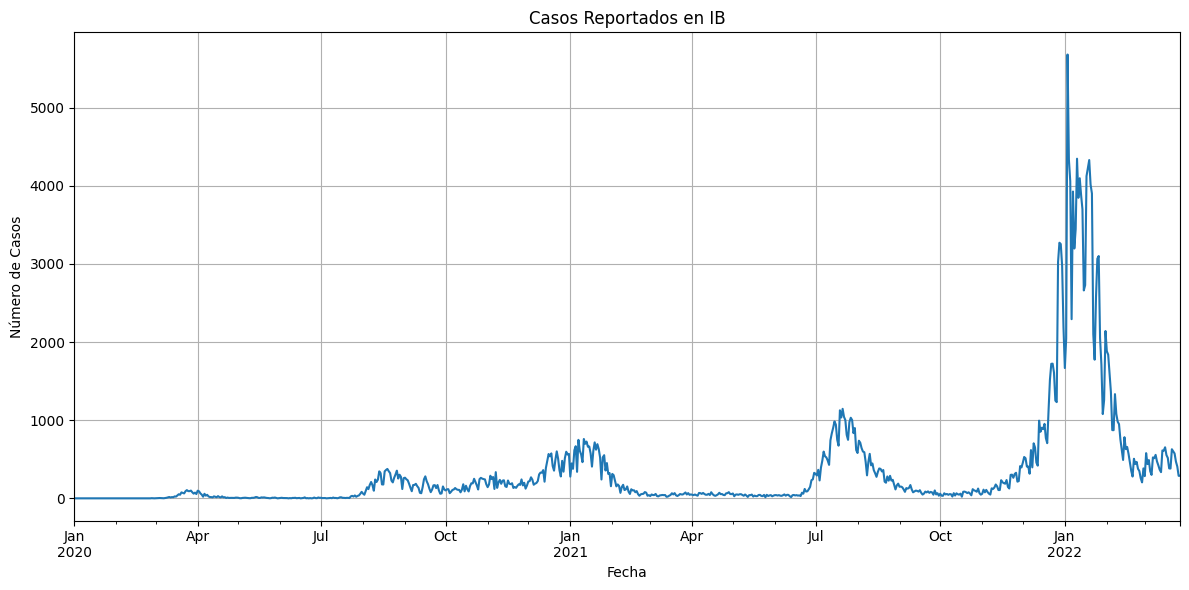

In [ ]:
# Convertir la columna 'fecha' a tipo datetime si no está en ese formato
casos_ib['fecha'] = pd.to_datetime(casos_ib['fecha'])

# Agrupar por fecha y sumar el número de casos
serie_temporal_ib = casos_ib.groupby('fecha')['num_casos'].sum()

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Crear el gráfico de línea
serie_temporal_ib.plot()

# Etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Número de Casos')
plt.title('Casos Reportados en IB')

# Mostrar el gráfico
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-13-67e91a970282>:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


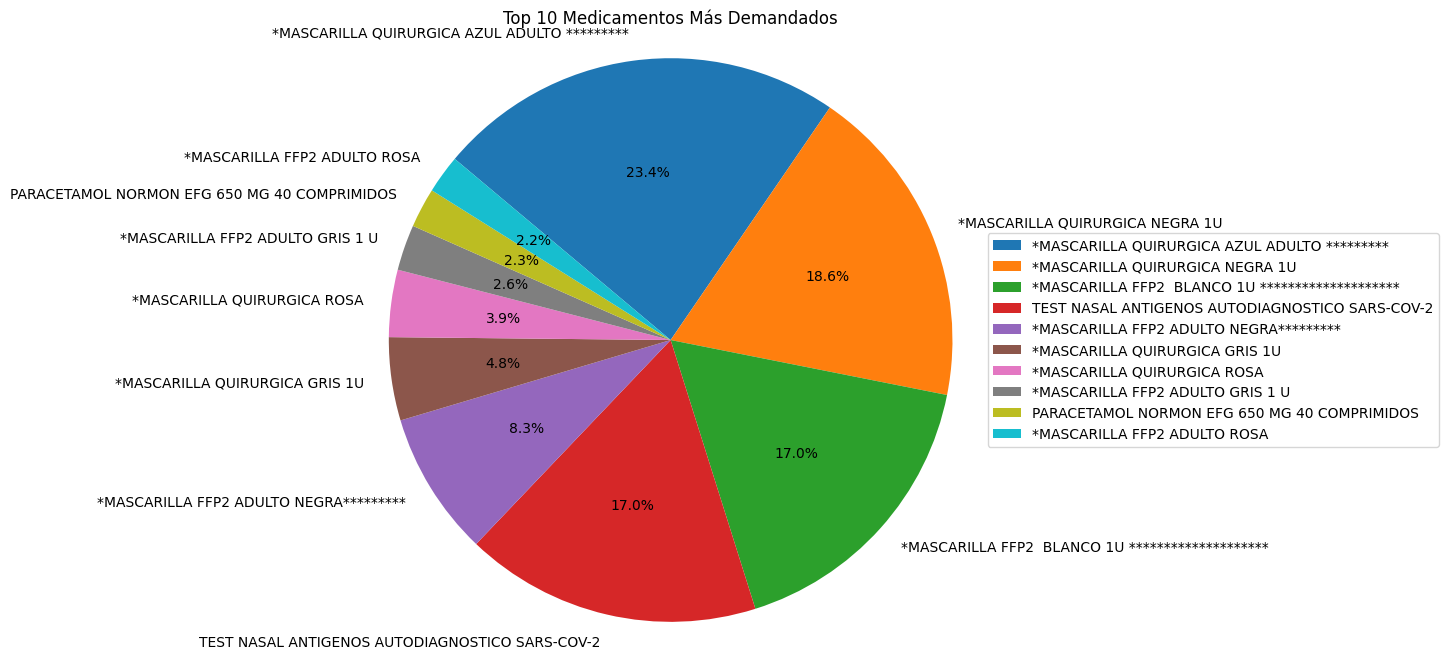

In [ ]:
# Paso 5: Identificación de medicamentos más demandados
medicamentos_mas_demandados = merged_data.groupby('Descripcion')['Cantidad'].sum().sort_values(ascending=False).head(10)

# Graficar los 10 medicamentos más demandados en un gráfico circular
plt.figure(figsize=(8, 8))
plt.pie(medicamentos_mas_demandados, labels=medicamentos_mas_demandados.index, autopct='%1.1f%%', startangle=140, counterclock=False)
plt.title('Top 10 Medicamentos Más Demandados')
plt.axis('equal')  # Hace que el gráfico de pastel sea circular
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


In [ ]:
# Seleccionar las filas correspondientes al artículo específico
ventas_articulo_especifico = merged_data[merged_data['IdArticu'] == 204617]
# Calcular la correlación entre las ventas del artículo específico y los casos de COVID en Baleares
correlacion_ventas_articulo_covid = ventas_articulo_especifico['Cantidad'].corr(casos_ib['num_casos'])

# Mostrar la correlación
print("Correlación entre las ventas del artículo específico y los casos de COVID en Baleares:")
print(correlacion_ventas_articulo_covid)


Correlación entre las ventas del artículo específico y los casos de COVID en Baleares:
0.016982173712463855


<ipython-input-15-2f010e93a2ff>:25: UserWarning: Glyph 132 (\x84) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 132 (\x84) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


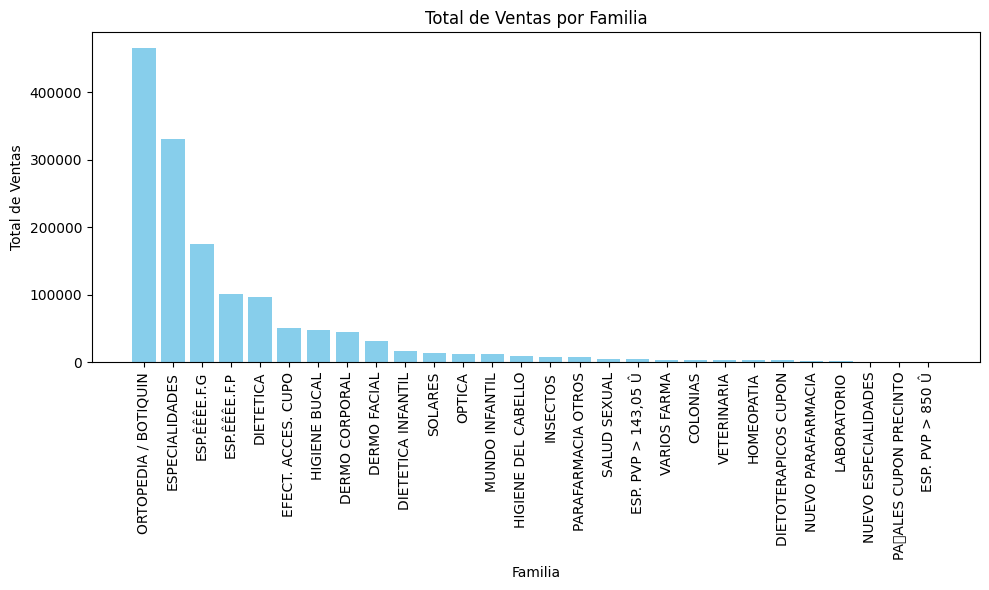

In [ ]:
# Unir las tablas 'articu' y 'ventas_lineas_total' por la columna 'IdArticu'
merged_data = pd.merge(ventas_lineas_total, articulos, on="IdArticu", how="left")

# Agrupar por la columna 'Familia' y sumar la columna 'Cantidad' para obtener el total de ventas por familia
ventas_por_familia = merged_data.groupby('Familia')['Cantidad'].sum().reset_index()

# Ordenar los resultados por el total de ventas de manera descendente
ventas_por_familia = ventas_por_familia.sort_values(by='Cantidad', ascending=False)

# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Crear el gráfico de barras
plt.bar(ventas_por_familia['Familia'], ventas_por_familia['Cantidad'], color='skyblue')

# Rotar las etiquetas del eje x para una mejor visualización
plt.xticks(rotation=90)

# Etiquetas y título
plt.xlabel('Familia')
plt.ylabel('Total de Ventas')
plt.title('Total de Ventas por Familia')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

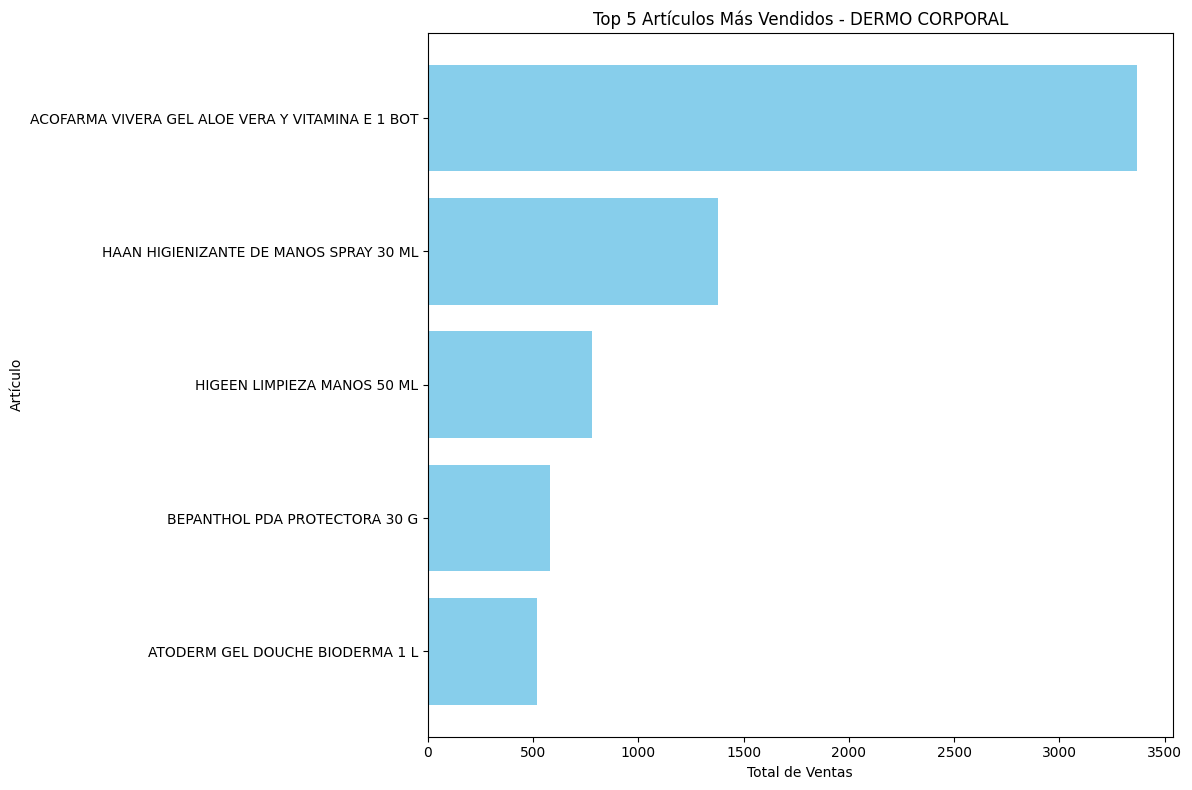

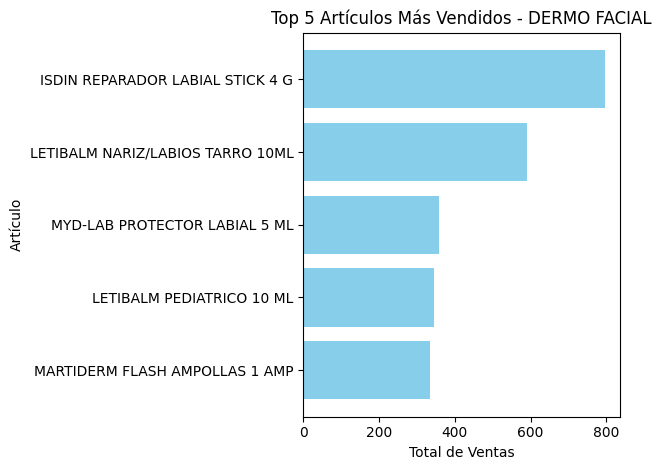

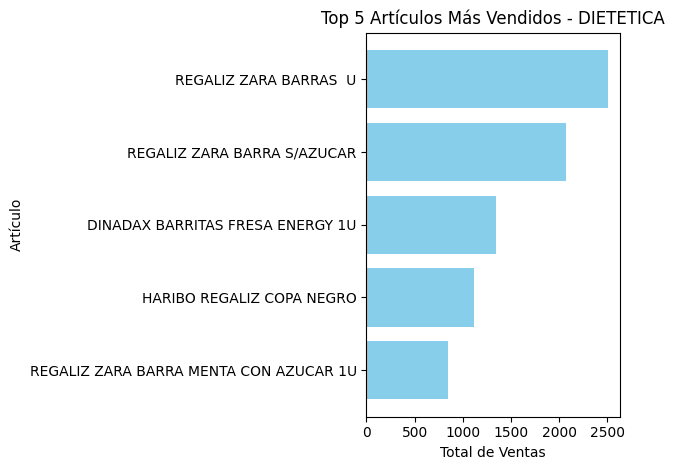

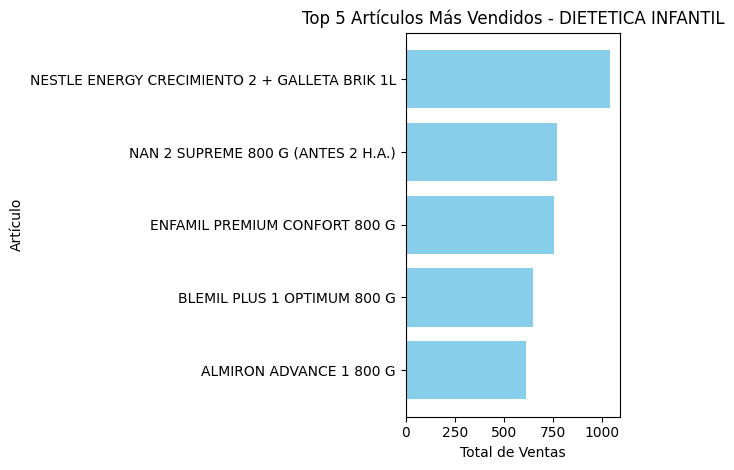

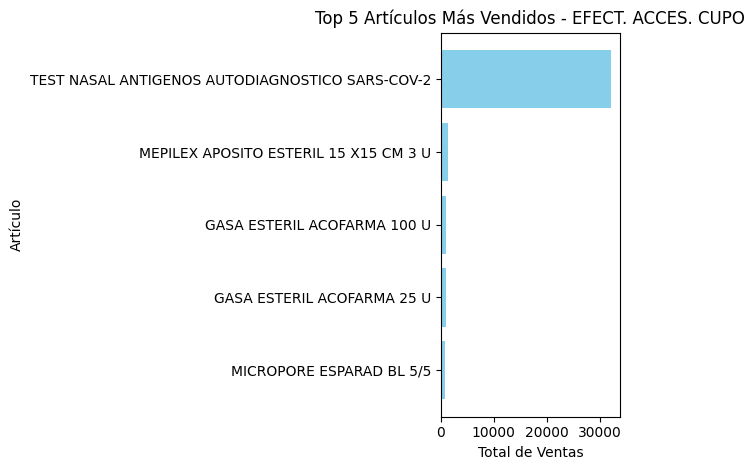

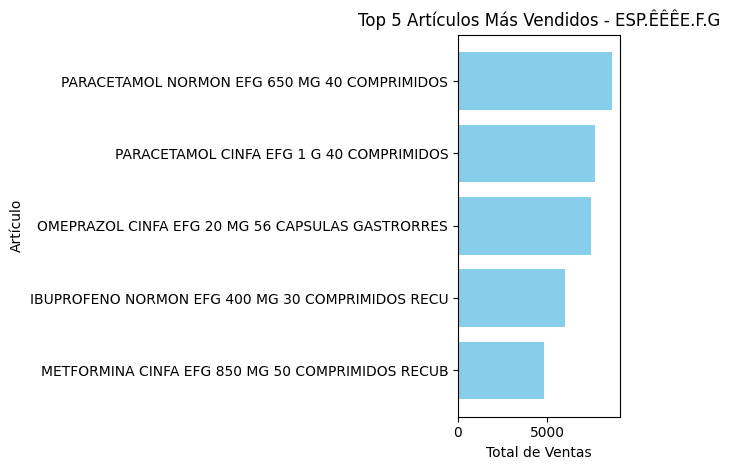

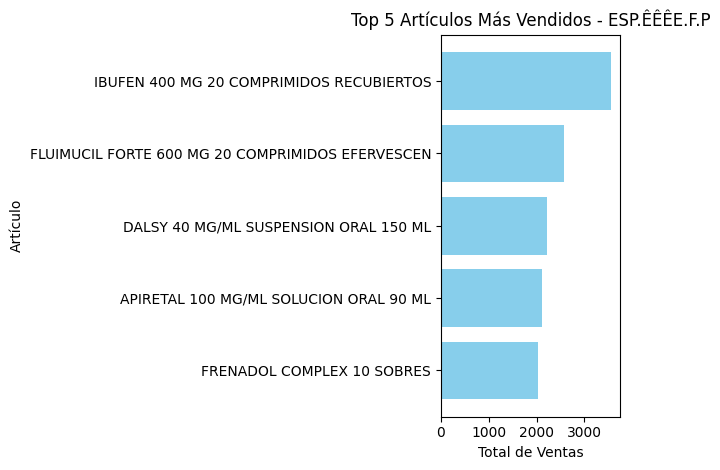

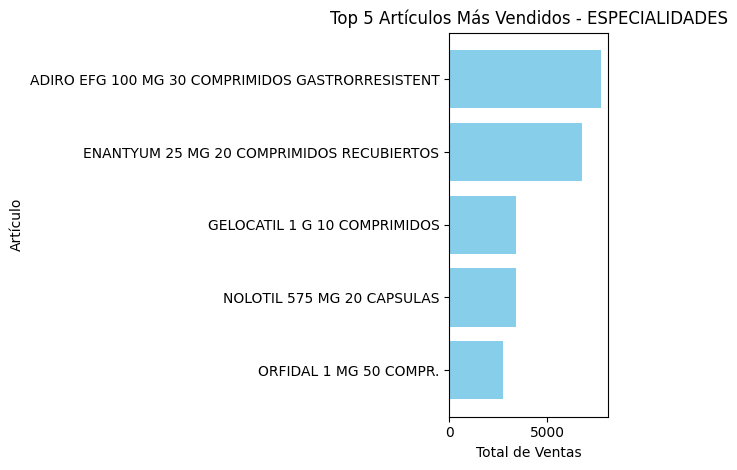

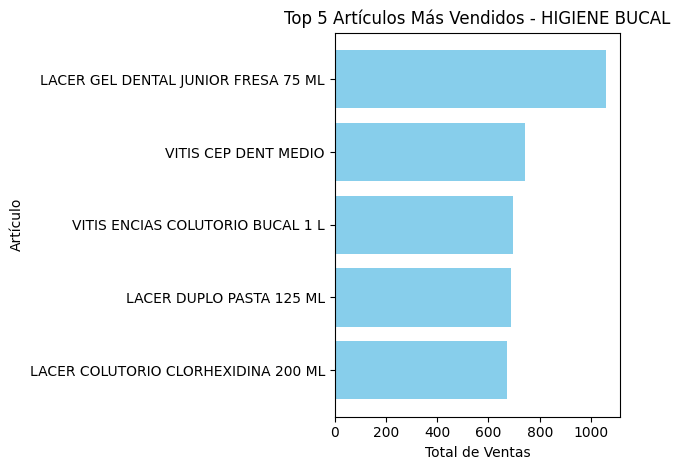

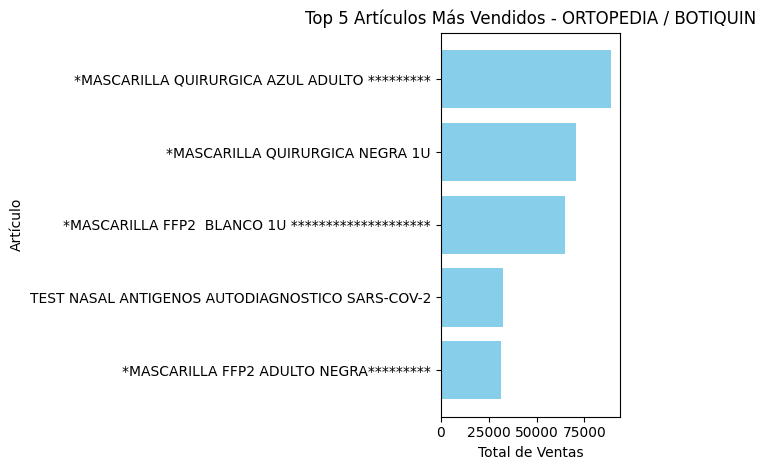

In [ ]:
# Obtener las 10 familias con más ventas
top_10_familias = ventas_por_familia.head(10)['Familia']

# Filtrar los datos originales por las 10 familias con más ventas
top_10_data = merged_data[merged_data['Familia'].isin(top_10_familias)]

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Iterar sobre cada familia y crear un gráfico de barras para los 5 artículos más vendidos
for familia, data in top_10_data.groupby('Familia'):
    top_5_articulos = data.groupby('Descripcion')['Cantidad'].sum().nlargest(5)
    plt.barh(top_5_articulos.index, top_5_articulos.values, color='skyblue')
    plt.xlabel('Total de Ventas')
    plt.ylabel('Artículo')
    plt.title(f'Top 5 Artículos Más Vendidos - {familia}')
    plt.gca().invert_yaxis()  # Invertir el eje y para mostrar el artículo más vendido en la parte superior
    plt.tight_layout()
    plt.show()


In [ ]:
# Crear una lista para almacenar la información de las familias con los 5 artículos más vendidos y sus ID y descripción de artículo
top_5_por_familia = []

# Iterar sobre cada familia
for familia, data in top_10_data.groupby('Familia'):
    # Obtener los 5 artículos más vendidos y sus IDs y descripciones de artículo
    top_5_articulos = data.groupby(['IdArticu', 'Descripcion'])['Cantidad'].sum().nlargest(5)
    top_5_ids_descripcion = [(id_articulo, descripcion) for id_articulo, descripcion in top_5_articulos.index]
    # Agregar la información a la lista
    top_5_por_familia.append((familia, top_5_ids_descripcion))

# Imprimir la lista
for familia, top_5_ids_descripcion in top_5_por_familia:
    print(f"-----------------------")
    print(f"Familia: {familia}")
    for i, (id_articulo, descripcion) in enumerate(top_5_ids_descripcion, 1):
        print(f"{id_articulo} - {descripcion}")


-----------------------
Familia: DERMO CORPORAL
201811 - ACOFARMA VIVERA GEL ALOE VERA Y VITAMINA E 1 BOT
38528 - HAAN HIGIENIZANTE DE MANOS SPRAY 30 ML
195774 - HIGEEN LIMPIEZA MANOS 50 ML
347765 - BEPANTHOL PDA PROTECTORA 30 G
327131 - ATODERM GEL DOUCHE BIODERMA 1 L
-----------------------
Familia: DERMO FACIAL
190120 - ISDIN REPARADOR LABIAL STICK 4 G
316729 - LETIBALM NARIZ/LABIOS TARRO 10ML
251009 - MYD-LAB PROTECTOR LABIAL 5 ML
247098 - LETIBALM PEDIATRICO 10 ML
177887 - MARTIDERM FLASH AMPOLLAS 1 AMP
-----------------------
Familia: DIETETICA
108365 - REGALIZ ZARA BARRAS  U
349 - REGALIZ ZARA BARRA S/AZUCAR
221484 - DINADAX BARRITAS FRESA ENERGY 1U
40132 - HARIBO REGALIZ COPA NEGRO
98666 - REGALIZ ZARA BARRA MENTA CON AZUCAR 1U
-----------------------
Familia: DIETETICA INFANTIL
163994 - NESTLE ENERGY CRECIMIENTO 2 + GALLETA BRIK 1L
183881 - NAN 2 SUPREME 800 G (ANTES 2 H.A.)
176886 - ENFAMIL PREMIUM CONFORT 800 G
189584 - BLEMIL PLUS 1 OPTIMUM 800 G
194858 - ALMIRON ADVANCE 1 

In [ ]:
# Suponiendo que 'nombre_articulo' es el nombre del artículo que estás buscando
nombre_articulo = "TEST NASAL ANTIGENOS AUTODIAGNOSTICO SARS-COV-2"

# Filtrar la tabla 'articu' por el nombre del artículo
filtro_nombre = articu['Descripcion'] == nombre_articulo
resultado_filtro = articu[filtro_nombre]

# Obtener el ID del artículo si hay algún resultado
if not resultado_filtro.empty:
    id_articulo = resultado_filtro.iloc[0]['IdArticu']
    print(f"El ID del artículo '{nombre_articulo}' es: {id_articulo}")
else:
    print(f"No se encontró ningún artículo con el nombre '{nombre_articulo}'")

El ID del artículo 'TEST NASAL ANTIGENOS AUTODIAGNOSTICO SARS-COV-2' es: 204617


<ipython-input-19-41549c0a0783>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casos_ib['fecha'] = pd.to_datetime(casos_ib['fecha'])
<ipython-input-19-41549c0a0783>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas_articulo['FechaHora'] = pd.to_datetime(ventas_articulo['FechaHora'])
<ipython-input-19-41549c0a0783>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

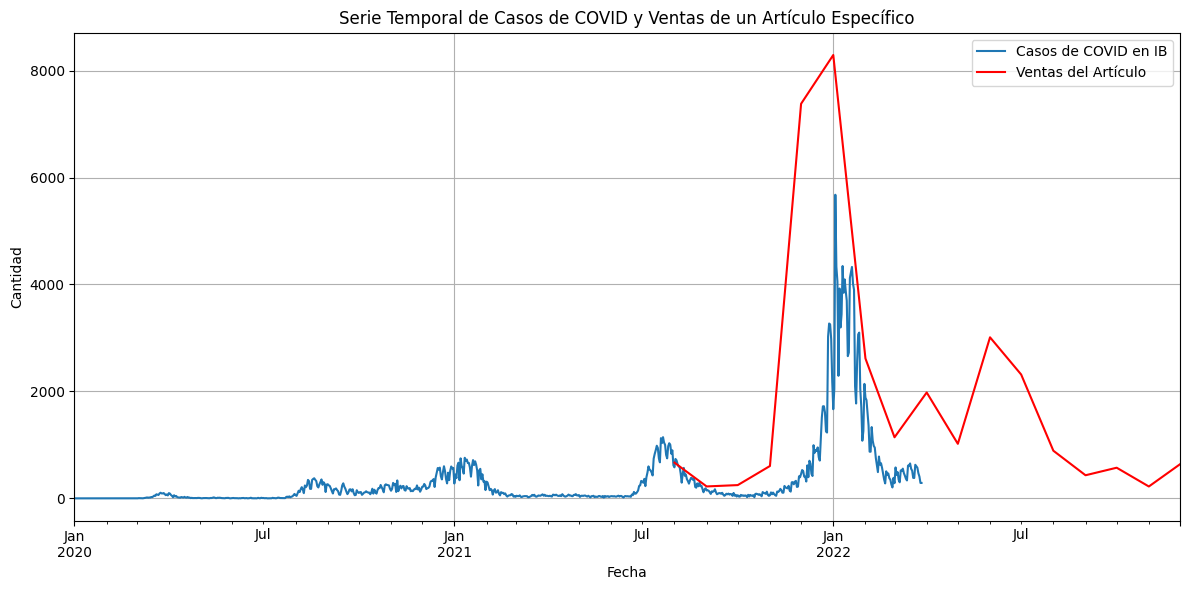

In [ ]:
import matplotlib.pyplot as plt

# Convertir la columna 'fecha' a tipo datetime si no está en ese formato
casos_ib['fecha'] = pd.to_datetime(casos_ib['fecha'])

# Agrupar por fecha y sumar el número de casos
serie_temporal_ib = casos_ib.groupby('fecha')['num_casos'].sum()

# Definir el ID del artículo que deseas analizar
id_articulo_deseado = 204617  # Puedes cambiarlo al ID del artículo que desees analizar

# Filtrar las ventas del artículo deseado
ventas_articulo = ventas_lineas_total[ventas_lineas_total['IdArticu'] == id_articulo_deseado]

# Convertir la columna 'FechaHora' a tipo de dato datetime si aún no lo es
ventas_articulo['FechaHora'] = pd.to_datetime(ventas_articulo['FechaHora'])

# Agregar una nueva columna 'Mes' que contenga el mes de la fecha
ventas_articulo['Mes'] = ventas_articulo['FechaHora'].dt.to_period('M')

# Agrupar las ventas por mes y sumar la cantidad vendida
ventas_por_mes = ventas_articulo.groupby('Mes')['Cantidad'].sum()

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Crear el gráfico de línea para la serie temporal de casos de COVID en Ibiza
serie_temporal_ib.plot(label='Casos de COVID en IB')

# Crear el gráfico de línea para la serie temporal de ventas del artículo específico
ventas_por_mes.plot(label='Ventas del Artículo', color='red')

# Etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Serie Temporal de Casos de COVID y Ventas de un Artículo Específico')

# Mostrar la leyenda
plt.legend()

# Mostrar el gráfico
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Convertir la columna de fecha de venta a tipo datetime si no lo está
ventas_lineas_total['FechaHora'] = pd.to_datetime(ventas_lineas_total['FechaHora'])

# Agrupar los datos por día y sumar la cantidad vendida en cada grupo
ventas_por_dia = ventas_lineas_total.groupby(ventas_lineas_total['FechaHora'].dt.date)['Cantidad'].sum()
ventas_por_dia
# Visualizar las primeras filas del DataFrame resultante
#print(ventas_por_dia.head())


FechaHora
2020-01-01     859
2020-01-02    1329
2020-01-03    1059
2020-01-04     932
2020-01-05     977
              ... 
2022-12-27    1754
2022-12-28    2086
2022-12-29    1421
2022-12-30    1642
2022-12-31    1372
Name: Cantidad, Length: 1096, dtype: int64

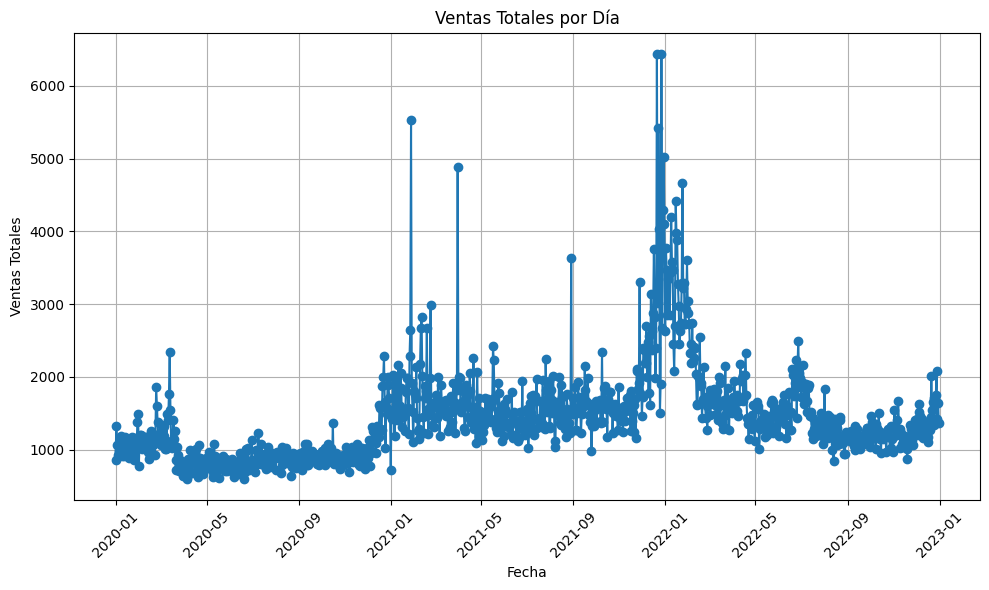

In [ ]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Graficar las ventas totales por día
plt.plot(ventas_por_dia.index, ventas_por_dia.values, marker='o', linestyle='-')

# Configurar el título y las etiquetas de los ejes
plt.title('Ventas Totales por Día')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)  # Rotar las etiquetas del eje x para mayor legibilidad

# Mostrar el gráfico
plt.grid(True)
plt.tight_layout()
plt.show()


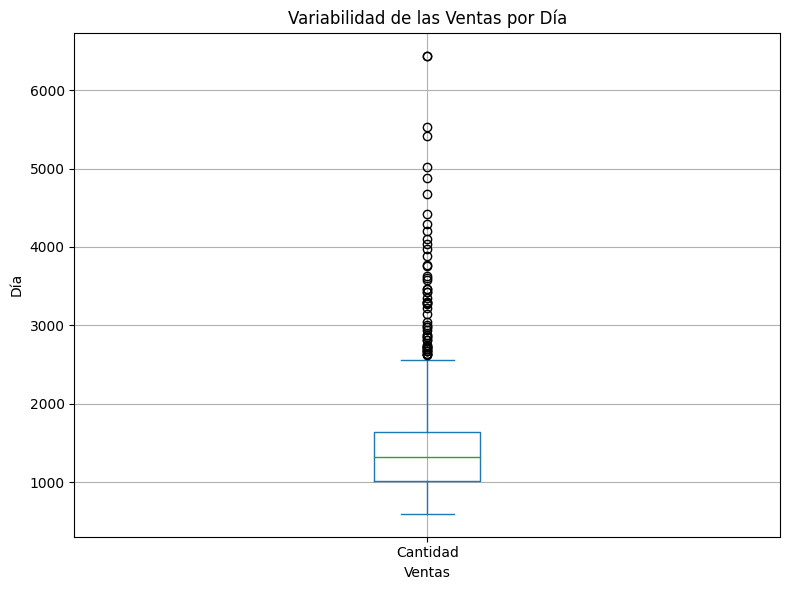

In [ ]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 6))

# Graficar un boxplot de las ventas por día
ventas_por_dia.plot(kind='box')

# Configurar el título y las etiquetas de los ejes
plt.title('Variabilidad de las Ventas por Día')
plt.xlabel('Ventas')
plt.ylabel('Día')

# Mostrar el gráfico
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Relación entre ventas y eventos de la pandemia


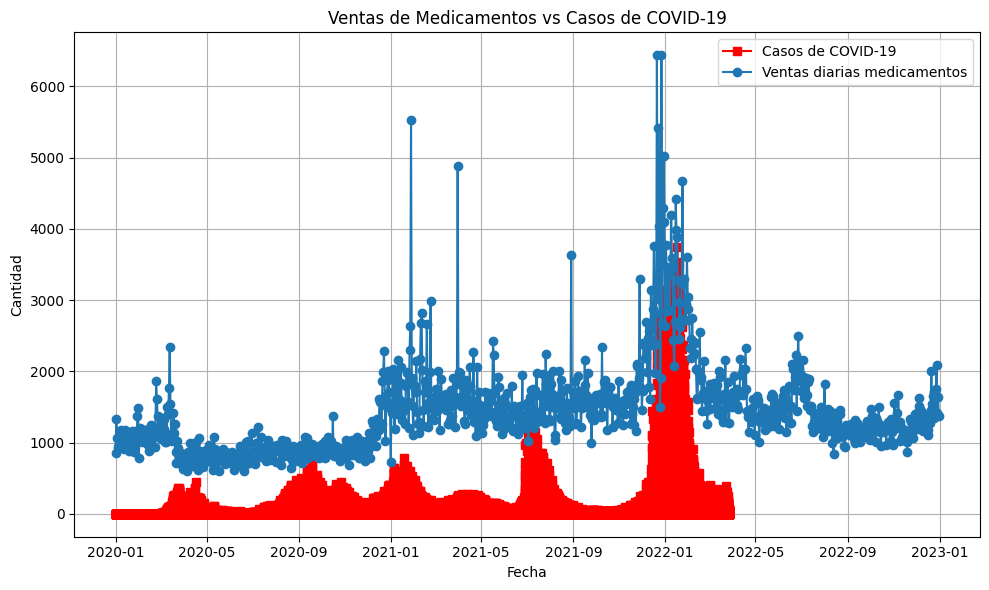

In [ ]:
# Convertir la columna 'FechaHora' a tipo de dato datetime
ventas_lineas_total['FechaHora'] = pd.to_datetime(ventas_lineas_total['FechaHora'])

# Asegurarse de que la columna 'Cantidad' sea numérica
ventas_lineas_total['Cantidad'] = pd.to_numeric(ventas_lineas_total['Cantidad'])

# Convertir la columna 'fecha' a tipo de dato datetime
casos['fecha'] = pd.to_datetime(casos['fecha'])

# Asegurarse de que la columna 'num_casos' sea numérica
casos['num_casos'] = pd.to_numeric(casos['num_casos'])

# Por ejemplo, graficar ventas junto con casos de COVID-19
# (Suponiendo que tienes datos de casos de COVID-19 en un DataFrame llamado 'casos_covid')
plt.figure(figsize=(10, 6))
plt.plot(casos['fecha'], casos['num_casos'], marker='s', linestyle='-', color='red', label='Casos de COVID-19')
plt.plot(ventas_por_dia.index, ventas_por_dia.values, marker='o', linestyle='-',  label='Ventas diarias medicamentos')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Ventas de Medicamentos vs Casos de COVID-19')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Crear un DataFrame pivote para tener las familias como columnas y las fechas como índices
ventas_por_familia_tiempo = merged_data.pivot_table(index='FechaHora', columns='Familia', values='Cantidad', aggfunc='sum')

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 8))

# Crear el gráfico de líneas para cada familia
for familia in ventas_por_familia_tiempo.columns:
    plt.plot(ventas_por_familia_tiempo.index, ventas_por_familia_tiempo[familia], label=familia)

# Rotar las etiquetas del eje x para una mejor visualización
plt.xticks(rotation=45)

# Etiquetas y título
plt.xlabel('Fecha')
plt.ylabel('Cantidad Vendida')
plt.title('Serie Temporal de Ventas por Familia')

# Mostrar la leyenda
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit


In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
train_features, test_features, train_labels, test_labels = train_test_split(merged_data[['IdVenta','FechaHora','IdArticu','Descripcion','FechaUltimaEntrada','FechaCaducidad','ProveedorHabitual','Laboratorio','IdFamilia','Familia','casos_covid','Cantidad', 'PVP', 'StockActual', 'Puc', 'Pmc', 'Pvp']], merged_data['Cantidad'], test_size=0.2, random_state=42)



#Modelo ARIMA

In [ ]:
modelo_arima = ARIMA(train_features['Cantidad'], order=(5,1,0))
modelo_arima_entrenado = modelo_arima.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
prediccion = modelo_arima_entrenado.forecast(steps=len(test_features))  # test_data son tus datos de prueba


#Modelo ARIMAX

In [ ]:
merged_data['casos_covid'] = casos['num_casos']

In [ ]:
modelo_arimax = ARIMA(merged_data['Cantidad'], order=(5,1,0), exog=merged_data['casos_covid'])
modelo_arimax_entrenado = modelo_arimax.fit()

KeyboardInterrupt: 

In [ ]:
futuros_casos_covid = [0] * 10  # Serie temporal de 10 ceros para casos de COVID-19 futuros

# Hacer predicciones futuras
predicciones_futuras = modelo_arimax_entrenado.forecast(steps=10, exog=futuros_casos_covid)

# Bosques Aleatorios (Random Forests):


In [ ]:
# train_features para Bosques Aleatorios
train_features = merged_data[['IdVenta', 'IdArticu', 'FechaUltimaEntrada', 'FechaCaducidad', 'ProveedorHabitual', 'Laboratorio', 'IdFamilia', 'Familia', 'casos_covid', 'Cantidad', 'PVP', 'StockActual', 'Puc', 'Pmc', 'Pvp']]

# train_labels para Bosques Aleatorios
train_labels = merged_data['Cantidad']



In [ ]:
# Crear modelo de Bosques Aleatorios
rf_model = RandomForestRegressor()

# Entrenar el modelo con características adicionales
rf_model.fit(train_features, train_labels)


In [ ]:
# Realizar predicciones en el conjunto de prueba
predictions = rf_model.predict(test_features)

# Evaluar el rendimiento del modelo
mse = mean_squared_error(test_labels, predictions)
print("Mean Squared Error:", mse)

# Redes Neuronales Recurrentes (RNN), como LSTM o GRU:


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

n_features = 15

# Definir modelo de red neuronal recurrente (LSTM)
model = Sequential()
model.add(LSTM(units=50, input_shape=(n_steps, n_features)))
model.add(Dense(units=1))

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')


In [ ]:
# Entrenar el modelo con los datos de secuencia temporal
model.fit(train_sequences, train_labels, epochs=100, batch_size=32)


In [ ]:
# Realizar predicciones en el conjunto de prueba
predictions = model.predict(test_sequences)

# Evaluar el rendimiento del modelo
mse = mean_squared_error(test_labels, predictions)
print("Mean Squared Error:", mse)
